# 12. Learned embeddings

Every other page here measures cells with CellProfiler: named features, one per shape or intensity or texture,
in a `var` that says which compartment and which channel each came from. A learned embedding replaces that
block with the output of a neural network — a few hundred numbers per well that mean nothing individually.

mantispy does not care. `X` is a matrix, and normalization, hit calling, consensus and the metrics all run on
one as readily as the other. What changes is the recipe around it, what you can no longer ask, and — the part
this page spends most of its length on — what you have to measure instead of assume.

This page uses JUMP-Lite {cite:p}`Munoz_2026`, which is built for exactly this comparison: four plates of the
JUMP Target-2 plate map, one from each of four laboratories, with **the same 1,536 wells** measured six ways —
five learned embeddings and one CellProfiler-equivalent feature set. Swapping the feature block is a
controlled experiment rather than a change of dataset.

Three things about how these numbers were made, because they bound every result below.

- **The images are lossy.** Every one of the six blocks was computed on JPEG-XL medium-quality images. Texture
  measurements and convolutional features are the two things most sensitive to compression, so this is not a
  neutral choice, and it is a property of the benchmark rather than of your screen.
- **One field of view per well.** Full Target-2 acquires nine; JUMP-Lite keeps one. So every cell count below
  is cells *in one field*, and this page cannot show you how to aggregate a model's per-site output — it can
  only tell you, which it does further down.
- **Only one of the six blocks needed segmentation.** `cp_measure` measures objects, so it needs a nucleus and
  a cell body found for every cell. The five embeddings read the whole field and segment nothing. That is the
  real difference between the two columns of this comparison, and it cuts both ways.

In [1]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import mantispy as mt

adata = mt.ds.jump_lite("openphenom")
adata

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/lPd87khm/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 1536 × 384
    obs: 'Metadata_id', 'Metadata_Source', 'Metadata_Batch', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Site', 'Metadata_model', 'Metadata_dataset', 'Metadata_compression', 'Metadata_CellCount', 'Metadata_JCP2022', 'Metadata_InChIKey', 'Metadata_Perturbation', 'Metadata_Control'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

384 numbers per well from OpenPhenom, a Cell Painting foundation model. The metadata is ordinary JUMP
metadata — source, batch, plate, well, and the compound each well received.

The four batches are four different laboratories running one plate map, which makes this a batch-correction
problem with a clean design: whatever separates `source_3` from `source_6` is not biology, because they
received the same compounds in the same wells.

In [2]:
counts = adata.obs.groupby("Metadata_Source", observed=True).agg(
    plate=("Metadata_Plate", "first"),
    wells=("Metadata_Well", "size"),
    controls=("Metadata_Control", "sum"),
    median_cells=("Metadata_CellCount", "median"),
)
counts["compounds"] = adata.obs.groupby("Metadata_Source", observed=True)["Metadata_Perturbation"].nunique()
counts["wells under 50 cells"] = (
    adata.obs.assign(thin=adata.obs["Metadata_CellCount"] < 50).groupby("Metadata_Source", observed=True)["thin"].sum()
)
counts

,plate,wells,controls,median_cells,compounds,wells under 50 cells
Metadata_Source,,,,,,
source_3,JCPQC016,384,64,264.0,302,28
source_4,BR00121438,384,64,189.0,302,61
source_5,ACPJUM012,384,64,336.0,302,13
source_6,110000293081,384,64,254.0,302,37


## Look at the plates first

One number per laboratory hides where the wells are. Four 384-well plates, coloured by how many cells were
found in the field.

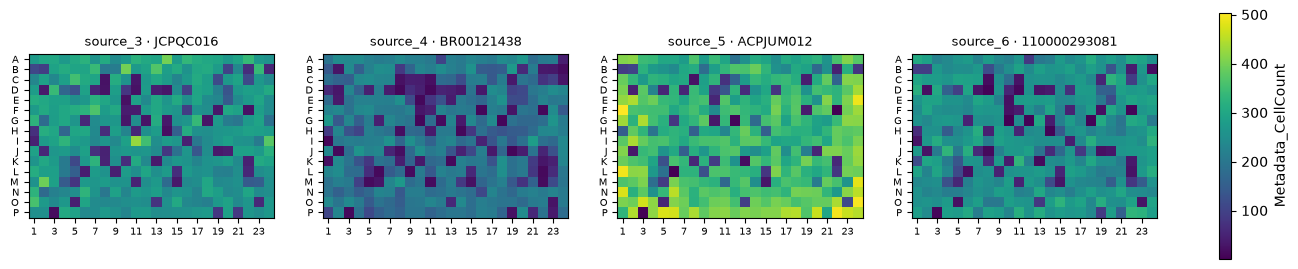

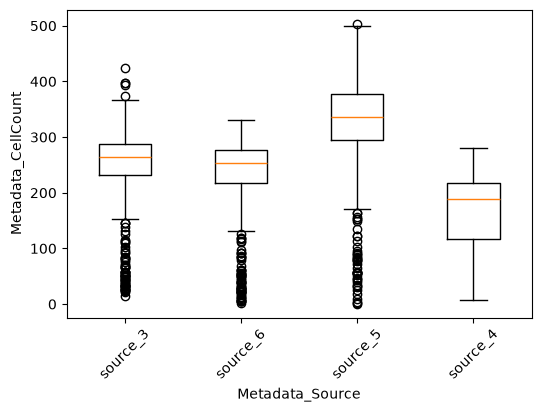

In [3]:
mt.pl.plate(adata, color="Metadata_CellCount", groupby="Metadata_Source", ncols=4)
plt.show()

ax = mt.pl.cell_counts(adata, groupby="Metadata_Source")
plt.show()

The laboratories do not seed comparably, and the thin wells are scattered across the plate rather than banked
against an edge — so they are not an evaporation artefact. Keep both facts; the section on cell count below
turns on them.

## What `var` no longer tells you

A CellProfiler feature name parses into a compartment, a feature group and a channel. `openphenom_nahualX_17`
has neither. The loader supplies the annotation columns the schema requires and leaves them empty, rather
than letting the name parser loose on names with no structure in them — that parser would read
`openphenom_nahualX_17` as the `nahualX` group of an `openphenom` object, and the screen would quietly
acquire feature families named after the model's own tensors.

In [4]:
pd.concat(
    {
        "openphenom": adata.var.head(3),
        "cp_measure": mt.ds.jump_lite("cp_measure").var.head(3),
    },
    names=["block"],
)[["object", "feature_group", "feature", "channel"]]

object  \
block                                                                 
openphenom openphenom_nahualX_0                                 NaN   
           openphenom_nahualX_1                                 NaN   
           openphenom_nahualX_10                                NaN   
cp_measure cell_0/max/ferretMaxFeretDiameter                   cell   
           cell_0/max/ferretMinFeretDiameter                   cell   
           cell_0/max/intensityIntensity_IntegratedIntensity   cell   

                                                             feature_group  \
block                                                                        
openphenom openphenom_nahualX_0                                        NaN   
           openphenom_nahualX_1                                        NaN   
           openphenom_nahualX_10                                       NaN   
cp_measure cell_0/max/ferretMaxFeretDiameter                        ferret   
           cell_0/max/ferretMinFeretDiameter                        ferret   
           cell_0/max/intensityIntensity_IntegratedIntensity     intensity   

                                                                                    feature  \
block                                                                                         
openphenom openphenom_nahualX_0                                                         NaN   
           openphenom_nahualX_1                                                         NaN   
           openphenom_nahualX_10                                                        NaN   
cp_measure cell_0/max/ferretMaxFeretDiameter                               MaxFeretDiameter   
           cell_0/max/ferretMinFeretDiameter                               MinFeretDiameter   
           cell_0/max/intensityIntensity_IntegratedIntensity  Intensity_IntegratedIntensity   

                                                             channel  
block                                                                 
openphenom openphenom_nahualX_0                                  NaN  
           openphenom_nahualX_1                                  NaN  
           openphenom_nahualX_10                                 NaN  
cp_measure cell_0/max/ferretMaxFeretDiameter                       0  
           cell_0/max/ferretMinFeretDiameter                       0  
           cell_0/max/intensityIntensity_IntegratedIntensity       0

That is the contrast the rest of the page is about, in one table. `cp_measure` names a compartment, a feature
group and a channel for every column; the embedding names nothing.

One caveat on the channel: `cp_measure` numbers its inputs `0` to `4` rather than naming them, because the
stain each index stands for lives in the acquisition metadata and not in the feature name. mantispy keeps the
index rather than guessing a stain.

This is not a defect of the embedding, it is the honest answer: it has no notion of a channel or a
compartment. The consequence is that anything keyed on the feature annotation has nothing to work with.
`pl.effect_sizes` colours its bars by feature family, `tl.feature_sets` groups features into sets, and the
CellProfiler blocklist names features to drop — none of them have anything to key on.

What survives is everything that treats a feature as an anonymous number: normalization, sphering, distances,
hit calling, consensus, and every metric. And the family colouring is recoverable, which is what the section
on interpreting an embedding does further down.

## Bringing your own embedding

`ds.jump_lite` is a convenience. An embedding you produced yourself is a matrix and a metadata frame, and
`io.stamp` is what puts it on the mantispy API surface.

In [5]:
# Pretend this came out of your own model, one row per well. Join on the index rather than slicing both by
# position: the six JUMP-Lite blocks are the same wells in different row orders, and so are most real
# pipelines' outputs.
wells_i_have = adata.obs_names[:8]
values = np.asarray(adata[wells_i_have].X, dtype=np.float32)
metadata = adata.obs.loc[wells_i_have, ["Metadata_Plate", "Metadata_Well", "Metadata_Perturbation", "Metadata_Control"]]

mine = ad.AnnData(values, obs=metadata.copy())
mine.var_names = [f"mymodel_{index}" for index in range(values.shape[1])]
mt.io.stamp(mine, resolution="well")
print(mt.io.validate(mine))

`io.stamp` supplies the annotation columns empty rather than parsing the feature names, and records the
resolution, so the object validates and can be written to h5ad. Supplying them empty is the point: the parser
would read `mymodel_17` as structure it does not have. It refuses a resolution whose required `obs` columns
are missing rather than letting the failure surface three calls later.

Two things worth copying from that cell. `values` is cast to **float32** — a model's output arrives as
float64, and at 100,000 wells by 1,536 dimensions that is 1.2 GB against 600 MB. And the warning is
*printed*, not counted: it names `Metadata_CellCount` as missing, which is the one column the rest of this
page shows you cannot do without.

### Aggregating a model's output to a well

JUMP-Lite gives one field of view per well, so this page never has to do it, and your screen will. The
difference matters more than it looks:

- A **CellProfiler** profile is a per-cell measurement aggregated over cells and fields, and the median is the
  pycytominer default because per-cell features are heavy-tailed. `tl.aggregate(by=("Metadata_Plate",
  "Metadata_Well"), func="median")` is the call.
- An **embedding** is a function of a whole image, so per-field embeddings are vectors in a learned basis. A
  per-coordinate median is not a point the model would ever emit. Prefer the mean, and if you take the median
  know that you have left the model's output manifold.

`tl.aggregate`'s `min_cells` guard counts rows, so it does nothing when the rows are already fields rather
than cells. Check the field count yourself.

## The recipe

**Normalize as usual.** The embedding is the model's raw output on each well's images: it carries the plate's
staining and illumination just as CellProfiler features do, so a per-plate normalization against the negative
controls is still the first step. Illumination correction is not part of this — it happens upstream, on the
images, and no per-plate normalization of the profiles substitutes for it.

In [6]:
mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")
degenerate = int(adata.var["degenerate_scale"].sum())
adata = adata[:, ~adata.var["degenerate_scale"].to_numpy()].copy()

classical = mt.ds.jump_lite("cp_measure")
mt.pp.normalize(classical, method="mad_robustize", by="Metadata_Plate", reference="negcon")
{
    "openphenom, unusable after normalizing": f"{degenerate} of 384",
    "cp_measure, unusable after normalizing": f"{int(classical.var['degenerate_scale'].sum())} of {classical.n_vars}",
}

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_10077/2372166604.py:6: UserWarning: 30 of 2550 features have no reference values to centre on in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon', because every value there is missing or infinite. Their centre is set to 0 where it is missing and their scale to 1, so the values measured outside the reference rows pass through unnormalized instead of becoming NaN, and are not comparable across groups. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy().
  mt.pp.normalize(classical, method="mad_robustize", by="Metadata_Plate", reference="negcon")
/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_10077/2372166604.py:6: UserWarning: 103 of 2550 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so t

{'openphenom, unusable after normalizing': '0 of 384',
 'cp_measure, unusable after normalizing': '133 of 2550'}

The two warnings above split that second number into its two very different causes: features with **no
spread** among a plate's control wells, and features with **no control values at all** to centre on. Both are
flagged in `var["degenerate_scale"]`, and only the first is what "constant among the controls" usually means.
Not one embedding dimension falls into either category.

### Select features on the CellProfiler block. Do not select them on an embedding.

This is the one step where the two block types genuinely need different treatment, and holding it identical
would be the unfair comparison, not the fair one.

`cp_measure` is a list of measurements, and measurements come with the usual pathologies: ones that never
vary, ones that duplicate each other, ones that run away to enormous values. pycytominer's standard selection
is built for exactly that. Run it and watch what each step is worth here.

In [7]:
PYCYTOMINER = ("variance_threshold", "correlation_threshold", "drop_na_columns", "blocklist")

selection = {}
for label, operations in {
    "none": ("drop_na_columns",),
    "pycytominer default": PYCYTOMINER,
    "default + drop_outliers": (*PYCYTOMINER, "drop_outliers"),
    "+ noise_removal": (*PYCYTOMINER, "drop_outliers", "noise_removal"),
}.items():
    trial = classical.copy()
    mt.pp.feature_select(trial, operations=operations, na_cutoff=0.0)
    trial = mt.pp.subset_features(trial)
    selection[label] = {
        "features": trial.n_vars,
        "largest |value|": float(np.abs(np.asarray(trial.X)).max()) if trial.n_vars else np.nan,
    }
pd.DataFrame(selection).T

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_10077/1950836588.py:11: UserWarning: feature_select flagged none of the 2550 features as selected; uns['mantispy']['feature_select'] says what each operation removed. Every cutoff here is an absolute threshold on the scale pp.normalize left the values on, so check it against that scale; noise_removal's stdev_cutoff is the usual cause.
  mt.pp.feature_select(trial, operations=operations, na_cutoff=0.0)


,features,largest |value|
none,2052.0,1.800000e+19
pycytominer default,547.0,1.100000e+19
default + drop_outliers,526.0,4.567456e+02
+ noise_removal,0.0,NaN


Read the second column. Left alone, `cp_measure` carries values of order 1e5 — unbounded shape moments that
survive a robust per-plate normalization because they are not constant, merely enormous. **The pycytominer
default does not remove them**, because they have plenty of variance and are not especially correlated. It
takes `drop_outliers`, which is in `pp.OPERATIONS` and not in the default set, and the difference is not
cosmetic: without it a PCA of this block is a PCA of about ten moments, and every number you then compute
from it is a statement about those ten.

`noise_removal` empties the block. Its cutoff is a standard deviation on the raw scale, and after
`mad_robustize` nothing survives it — a reminder that a selection step tuned for one normalization is not
portable to another.

So this page runs the standard selection plus `drop_outliers` on `cp_measure`, and nothing at all on the
embeddings. The argument for the second half is that the dimensions of an embedding are a basis rather than a
list of measurements: dropping some of them because they correlate discards the geometry the model learned.
That argument is about *variance and correlation* filters, though, and it does not cover every filter. The
one that does apply is reproducibility, which uses the replicate structure rather than the feature's own
distribution.

In [8]:
icc = adata.copy()
mt.pp.feature_reproducibility(icc, groupby="Metadata_Perturbation", min_icc=0.2)
{
    "dimensions with ICC > 0.2": f"{int(icc.var['icc_selected'].sum())} of {icc.n_vars}",
    "median ICC": round(float(icc.var["icc"].median()), 3),
}

{'dimensions with ICC > 0.2': '351 of 384', 'median ICC': 0.502}

That is a number to report rather than a filter to apply blindly, and it is the honest substitute for the
blocklist: the blocklist matches feature *names* and has nothing to say about an embedding — on `cp_measure`
it also matches nothing, because these are not CellProfiler's names either.

## Comparing six feature sets

The question is not whether an embedding works, but how it compares with the alternatives on the same wells.
Two readouts:

- **`tl.map`** — mean average precision. Rank every other profile by similarity to a query and ask whether
  its replicates come first. The pairs are defined so that a replicate must come from a *different
  laboratory*, which is the cross-site reproducibility question, and copairs gives every compound a
  permutation p-value that is then BH-corrected. This is the metric the JUMP benchmarks report
  {cite:p}`Kalinin_2025,Arevalo_2024`, and it is the only one of the two that scales: the
  similarity-matrix readouts build a dense n-by-n matrix and stop at about 22,000 profiles.
- **`metrics.known_relationships`** — of the compounds annotated to act on the same gene, how many end up in
  either tail of the similarity distribution?

Each is measured under three alignments: the principal components alone, `pp.tvn`, and `pp.harmony`, which
ranked top-three in every scenario of the batch-correction benchmark {cite:p}`Arevalo_2024` and is the last
step of the JUMP recipe. `pp.harmony` needs the optional extra, `pip install 'mantispy[harmony]'`.

In [9]:
targets = mt.ds.jump_lite_targets()


def prepared(model):
    """Load one feature set and align it three ways.

    The CellProfiler block gets the standard selection; the embeddings get none, for the reason above.
    """
    wells = mt.ds.jump_lite(model)
    mt.pp.normalize(wells, method="mad_robustize", by="Metadata_Plate", reference="negcon")
    wells = wells[:, ~wells.var["degenerate_scale"].to_numpy()].copy()
    operations = (*PYCYTOMINER, "drop_outliers") if model == "cp_measure" else ("drop_na_columns",)
    mt.pp.feature_select(wells, operations=operations, na_cutoff=0.0)
    wells = mt.pp.subset_features(wells)
    sc.pp.pca(wells, n_comps=50)
    mt.pp.tvn(wells, batch_key="Metadata_Source", use_rep="X_pca", key_added="X_tvn")
    mt.pp.harmony(wells, batch_key="Metadata_Source", use_rep="X_pca", key_added="X_harmony")
    return wells


def treated_profiles(wells, rep):
    """One alignment of the treated wells, as an object the metrics can score."""
    treated = ~wells.obs["Metadata_Control"].to_numpy()
    profiles = ad.AnnData(np.asarray(wells.obsm[rep], dtype=np.float32)[treated], obs=wells.obs[treated].copy())
    mt.io.stamp(profiles, resolution="well")
    return profiles


blocks = {model: prepared(model) for model in mt.ds.JUMP_LITE_MODELS}
{model: wells.n_vars for model, wells in blocks.items()}

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_10077/2459572423.py:9: UserWarning: 30 of 2550 features have no reference values to centre on in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon', because every value there is missing or infinite. Their centre is set to 0 where it is missing and their scale to 1, so the values measured outside the reference rows pass through unnormalized instead of becoming NaN, and are not comparable across groups. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy().
  mt.pp.normalize(wells, method="mad_robustize", by="Metadata_Plate", reference="negcon")
/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_10077/2459572423.py:9: UserWarning: 103 of 2550 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they 

{'openphenom': 384,
 'dinov2': 384,
 'dinov2_random': 384,
 'subcell': 1536,
 'morphem': 1920,
 'cp_measure': 526}

In [10]:
rng = np.random.default_rng(0)
scored_profiles = {}


def scored(name, wells, rep):
    """Cross-laboratory mAP on wells, and target recall on consensus profiles against its own null."""
    profiles = treated_profiles(wells, rep)
    mt.tl.map(
        profiles,
        pos_sameby=["Metadata_Perturbation"],
        pos_diffby=["Metadata_Source"],  # a replicate pair has to cross laboratories
        neg_diffby=["Metadata_Perturbation"],
        use_rep=None,
        null_size=500,
        seed=0,
    )
    per_compound = profiles.uns["mantispy"]["map"]
    scored_profiles[name, rep] = profiles  # kept so the per-compound panels below need not score again

    consensus = mt.tl.consensus(profiles, method="median", min_replicates=1)
    recall = float(mt.metrics.known_relationships(consensus, targets)["value"].iloc[0])
    # The chance level is not 10%: it depends on how this particular representation spreads its pairs, so it
    # has to be measured by shuffling which compound each gene is annotated to.
    null = np.array(
        [
            float(
                mt.metrics.known_relationships(
                    consensus, targets.assign(target=rng.permutation(targets["target"].to_numpy()))
                )["value"].iloc[0]
            )
            for _ in range(100)
        ]
    )
    return {
        "mAP": float(per_compound["mean_average_precision"].mean()),
        "significant": int(per_compound["below_corrected_p"].sum()),
        "target recall": recall,
        "recall null": float(null.mean()),
        "recall p": float((null >= recall).mean()),
        "source variance": float(mt.metrics.pc_regression(wells, key="Metadata_Source", use_rep=rep)["value"].iloc[0]),
    }


comparison = pd.DataFrame(
    [
        {"model": model, "alignment": rep, **scored(model, wells, rep)}
        for model, wells in blocks.items()
        for rep in ("X_pca", "X_tvn", "X_harmony")
    ]
)
comparison.pivot(index="model", columns="alignment", values=["mAP", "significant"]).round(3)

mAP               significant            
alignment     X_harmony  X_pca  X_tvn   X_harmony X_pca X_tvn
model                                                        
cp_measure        0.073  0.050  0.026        68.0   0.0   0.0
dinov2            0.069  0.031  0.029        50.0   0.0   0.0
dinov2_random     0.010  0.009  0.010         0.0   0.0   0.0
morphem           0.087  0.027  0.035        72.0   0.0   0.0
openphenom        0.040  0.016  0.018         0.0   0.0   0.0
subcell           0.074  0.027  0.022        55.0   0.0   0.0

`significant` counts the compounds whose mAP survives a BH correction over the 301 tested, which is the
number a screener actually cares about: how many compounds would you have called.

Three things to read out of that table.

**The untrained model behaves like one.** `dinov2_random` is the same architecture with random weights, and
it is the control for the whole comparison. Its mAP sits at the floor under every alignment, because random
projections of an image do not reproduce across laboratories, and no correction manufactures structure out of
noise. Any pipeline that reports a trained model doing no better than this one has a bug, not a finding.

**Alignment matters more than the choice of model.** Every trained block roughly doubles its mAP under
`pp.harmony`, and the spread between blocks under any one alignment is smaller than the spread between
alignments for any one block. The unaligned columns call no compound at all.

**The CellProfiler-equivalent set is not behind.** `cp_measure` is at the top of the unaligned column and
near the top under Harmony, on a benchmark built to show embeddings off. The independent benchmark of these
six reaches the same conclusion {cite:p}`Munoz_2026`: on Cell Painting, classical features remain a strong
baseline, and the case for an embedding is throughput and the absence of a segmentation step rather than a
large accuracy gain.

Before reading the ranking, look at what 50 components means for each block.

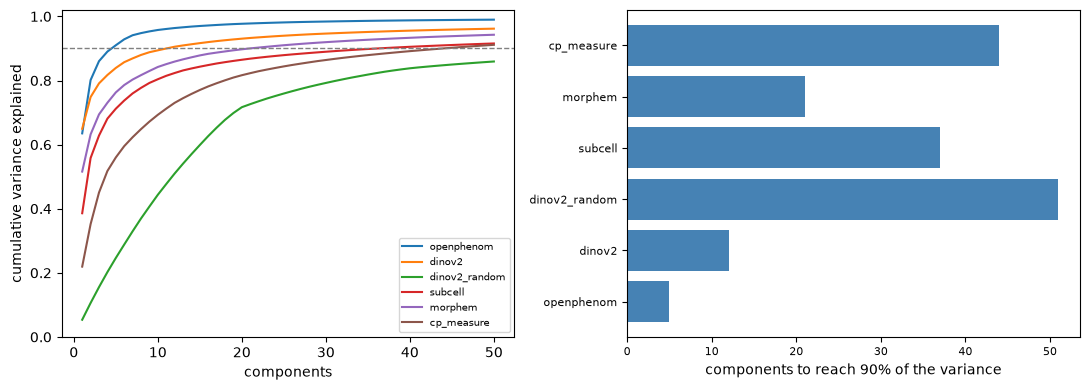

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for model, wells in blocks.items():
    ratio = wells.uns["pca"]["variance_ratio"]
    axes[0].plot(np.arange(1, len(ratio) + 1), np.cumsum(ratio), label=model, lw=1.5)
axes[0].axhline(0.9, color="grey", ls="--", lw=1)
axes[0].set(xlabel="components", ylabel="cumulative variance explained", ylim=(0, 1.02))
axes[0].legend(fontsize=7)

reach = {
    model: int(np.searchsorted(np.cumsum(wells.uns["pca"]["variance_ratio"]), 0.9) + 1)
    for model, wells in blocks.items()
}
axes[1].barh(list(reach), list(reach.values()), color="steelblue")
axes[1].set_xlabel("components to reach 90% of the variance")
axes[1].tick_params(labelsize=8)
fig.tight_layout()
plt.show()

This is the caveat on every row of the table above: `sc.pp.pca(n_comps=50)` is a mild truncation of one block
and an aggressive one of another. The trained embeddings collapse onto very few components; the untrained
model spreads its variance almost evenly, which is what a random projection does and is the clearest single
picture of what "trained" bought. Fifty components is not a neutral choice held constant across the six — it
is the same number applied to six different geometries.

### What is chance, really?

`metrics.known_relationships` counts annotated pairs falling in either tail of the similarity distribution,
and a fixed tail width invites the assumption that a map with no information scores 10%. It does not. The
statistic has a conservative tie rule, and how many pairs land in a tail depends on the shape of the
similarity distribution, which is a property of each representation. So the chance level has to be measured,
by shuffling which compound each gene is annotated to and rerunning.

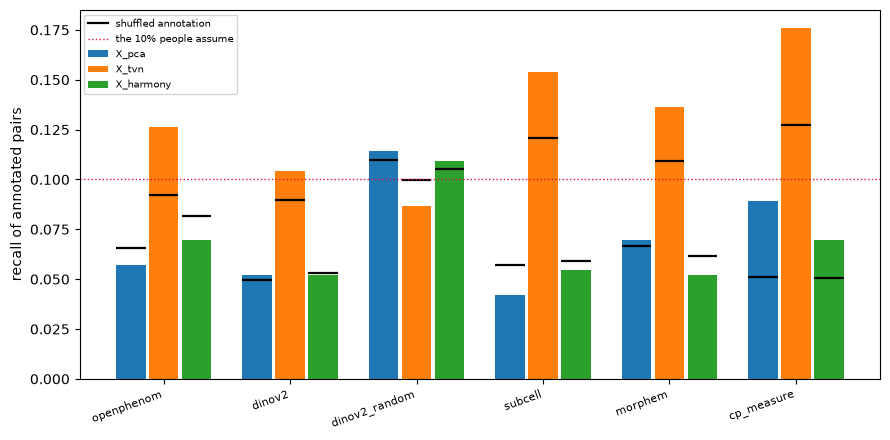

target recall               recall null                recall p  \
alignment         X_harmony  X_pca  X_tvn   X_harmony  X_pca  X_tvn X_harmony   
model                                                                           
cp_measure            0.069  0.089  0.176       0.051  0.051  0.127      0.00   
dinov2                0.052  0.052  0.104       0.053  0.050  0.089      0.53   
dinov2_random         0.109  0.114  0.087       0.105  0.110  0.100      0.30   
morphem               0.052  0.069  0.136       0.062  0.067  0.109      0.91   
openphenom            0.069  0.057  0.127       0.082  0.066  0.092      0.91   
subcell               0.055  0.042  0.154       0.059  0.057  0.121      0.70   

                           
alignment     X_pca X_tvn  
model                      
cp_measure     0.00  0.00  
dinov2         0.32  0.00  
dinov2_random  0.26  0.97  
morphem        0.40  0.00  
openphenom     0.85  0.00  
subcell        0.98  0.00

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = list(blocks)
width = 0.26
for offset, alignment in zip((-width, 0, width), ("X_pca", "X_tvn", "X_harmony"), strict=True):
    block = comparison[comparison["alignment"] == alignment].set_index("model").loc[order]
    x = np.arange(len(order)) + offset
    ax.bar(x, block["target recall"], width * 0.9, label=alignment)
    # the shuffled-annotation level for this exact representation
    ax.hlines(block["recall null"], x - width * 0.45, x + width * 0.45, color="black", lw=1.6)
ax.plot([], [], color="black", lw=1.6, label="shuffled annotation")
ax.axhline(0.10, color="crimson", ls=":", lw=1, label="the 10% people assume")
ax.set_xticks(np.arange(len(order)), order, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("recall of annotated pairs")
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

comparison.pivot(index="model", columns="alignment", values=["target recall", "recall null", "recall p"]).round(3)

The black bars are chance for that representation, and they are nowhere near a constant 10%. Read every
recall against the bar sitting on it, not against the red line.

Once you do, the readout says something clean, and something different from what the raw numbers suggest.
**`pp.tvn` lifts recall above its own null on every trained embedding and on `cp_measure`. Without it, no
embedding clears its own null under any alignment — but `cp_measure` clears it under all three.** And the
untrained model never clears it: its apparently high raw recall, the highest in the unaligned column, is
entirely a property of its null, which is high because a near-random projection spreads pairs into the tails.
That is exactly the trap a fixed baseline sets, and it would have made the untrained control look like the
best model on the page.

Keeping an untrained model in the comparison is the cheapest check that a pipeline measures anything, and
this is the second time on this page it has earned its place.

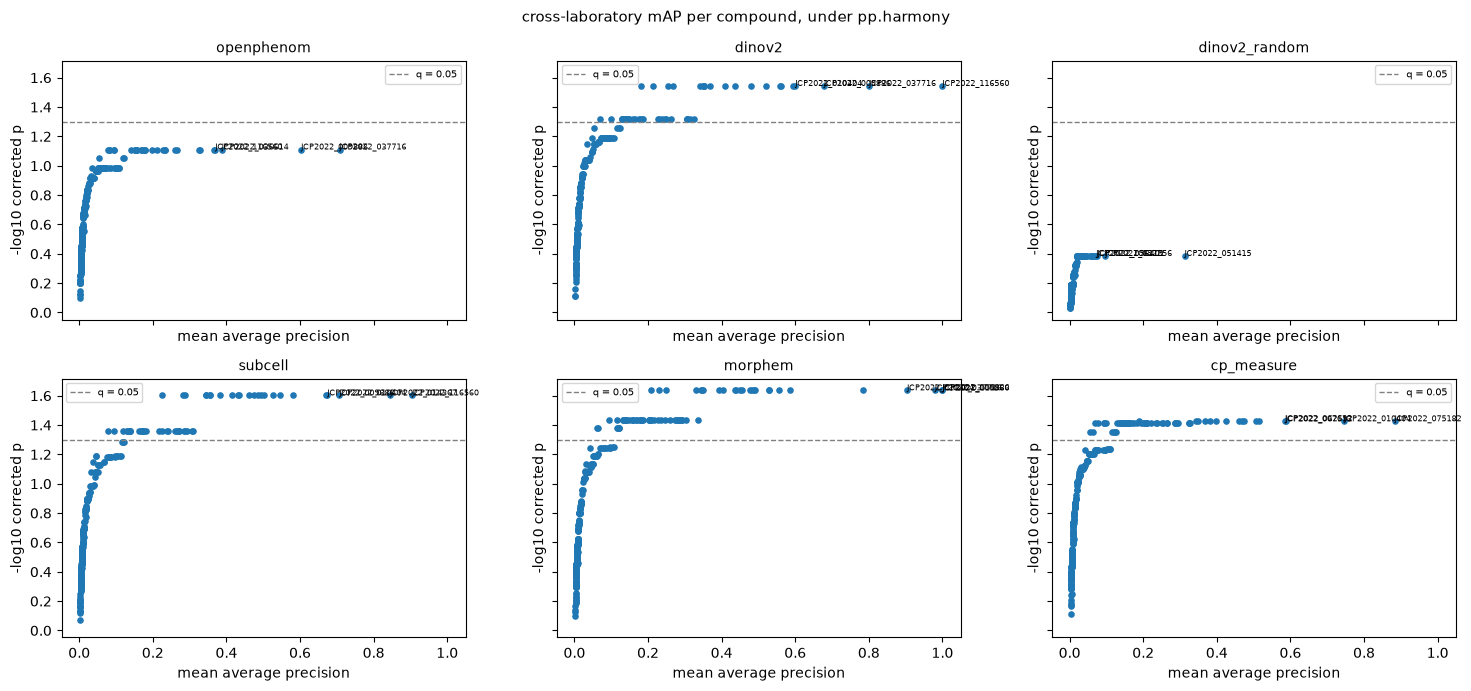

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, sharey=True)
for ax, model in zip(axes.ravel(), blocks, strict=True):
    mt.pl.map(scored_profiles[model, "X_harmony"], label_top=4, ax=ax)
    ax.set_title(model, fontsize=10)
fig.suptitle("cross-laboratory mAP per compound, under pp.harmony", fontsize=11)
fig.tight_layout()
plt.show()

An aggregate mAP hides whether it came from many mediocre compounds or a few excellent ones. These panels
show which, and name the compounds at the top.

## The laboratories

The same `metrics.pc_regression`, now on the source.

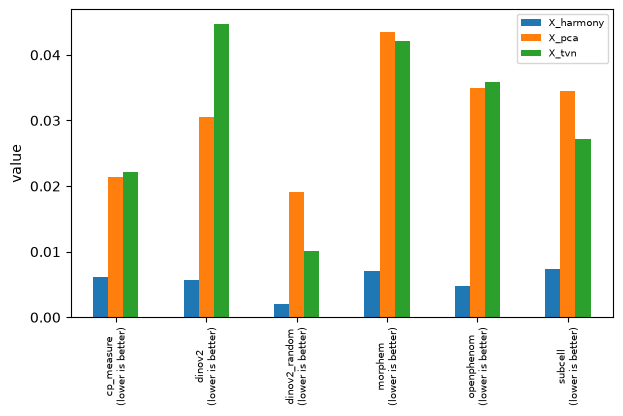

alignment,X_harmony,X_pca,X_tvn
model,,,
cp_measure,0.006,0.021,0.022
dinov2,0.006,0.030,0.045
dinov2_random,0.002,0.019,0.010
morphem,0.007,0.044,0.042
openphenom,0.005,0.035,0.036
subcell,0.007,0.034,0.027


In [14]:
# pl.metrics groups by "metric" and draws one bar per "representation", which here is one group per
# feature set and one bar per alignment.
mt.pl.metrics(
    comparison.rename(columns={"model": "metric", "alignment": "representation", "source variance": "value"}).assign(
        better="lower"
    )[["metric", "representation", "value", "better"]]
)
plt.show()
comparison.pivot(index="model", columns="alignment", values="source variance").round(3)

Harmony takes the laboratory down to a fraction of a percent on every feature set. TVN leaves it roughly
where it was. That is consistent with what the two do — Harmony mixes the batches in every local
neighbourhood, while TVN aligns each batch's control covariance to the pooled one — and it is why the two
readouts disagree.

Read this together with the tables above, not instead of them: a correction that leaves the batch structure
intact has done nothing, and one that removes it may have taken the biology with it. Neither readout alone
tells you which happened. Which alignment to use is a decision about what the screen is for, not a default.

## Putting the names back on

The hardest thing about an embedding is that a result has no vocabulary. A CellProfiler hit comes with
"nuclear texture went down"; an embedding hit comes with a compound ID and nothing else.

This dataset is the one place you can fix that cleanly, because the same wells were measured both ways. Use
the named block to name the unnamed one: regress every CellProfiler measurement on the embedding's
components and ask how much of it the embedding already carries.

One thing to get right first. **The six blocks hold the same wells in different row orders.** Stacking two
of them positionally is silent and wrong, so align on the index.

In [15]:
embedding = blocks["openphenom"]

# The comparison above decorrelated cp_measure, which is right for building a representation and wrong here:
# the question is how much of each named measurement the embedding carries, so keep them all and drop only
# the runaway ones.
named = classical[:, ~classical.var["degenerate_scale"].to_numpy()].copy()
mt.pp.feature_select(named, operations=("drop_na_columns", "drop_outliers"), na_cutoff=0.0)
named = mt.pp.subset_features(named)

aligned = named[named.obs_names.get_indexer(embedding.obs_names)].copy()
{
    "named measurements kept": named.n_vars,
    "same set of wells": set(embedding.obs_names) == set(named.obs_names),
    "same row order": bool((embedding.obs_names == named.obs_names).all()),
    "rows that had to move": int((embedding.obs_names != named.obs_names).sum()),
}

{'named measurements kept': 1857,
 'same set of wells': True,
 'same row order': False,
 'rows that had to move': 1534}

In [16]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold


measurements = np.asarray(aligned.X, dtype=float)
measurements = (measurements - measurements.mean(0)) / np.where(measurements.std(0) > 0, measurements.std(0), 1)


def carried(wells):
    """Out-of-fold R^2 of every CellProfiler measurement, predicted from this block's components."""
    # Every block has its own row order, so each one has to be put into the order `aligned` is in. Skipping
    # this is silent: the regression simply finds nothing, and an informative block scores like a random one.
    X = np.asarray(wells[wells.obs_names.get_indexer(aligned.obs_names)].obsm["X_pca"], dtype=float)
    Y = measurements

    predicted = np.zeros_like(Y)
    for train, test in KFold(5, shuffle=True, random_state=0).split(X):
        predicted[test] = RidgeCV(alphas=np.logspace(-1, 4, 12)).fit(X[train], Y[train]).predict(X[test])
    return pd.Series(1 - ((Y - predicted) ** 2).sum(0) / (Y**2).sum(0), index=aligned.var_names)


explained = pd.DataFrame({name: carried(blocks[name]) for name in ("openphenom", "dinov2", "dinov2_random")})
explained["feature_group"] = aligned.var["feature_group"].to_numpy()
explained["object"] = aligned.var["object"].to_numpy()

by_group = explained.groupby("feature_group", observed=True)[["openphenom", "dinov2", "dinov2_random"]].median()
by_group.sort_values("openphenom", ascending=False).round(3)

,openphenom,dinov2,dinov2_random
feature_group,,,
texture,0.818,0.749,0.185
ferret,0.677,0.704,0.156
intensity,0.623,0.577,0.145
radial_distribution,0.567,0.552,0.176
radial_zernikes,0.490,0.521,0.146
sizeshape,0.483,0.586,0.016
zernike,0.468,0.537,0.141


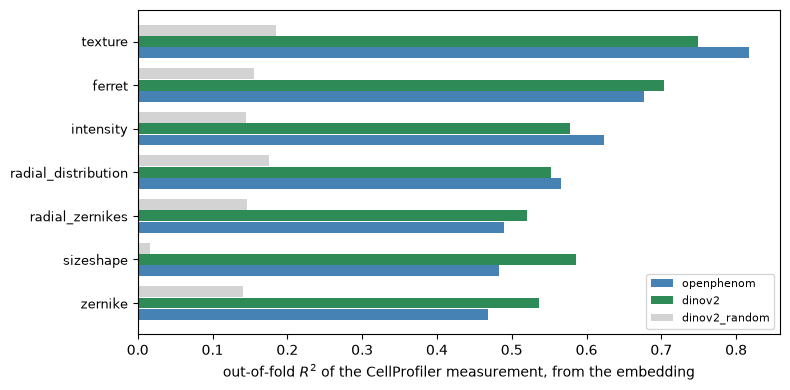

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
panel = by_group.sort_values("openphenom")
positions = np.arange(len(panel))
for offset, name, colour in (
    (-0.26, "openphenom", "steelblue"),
    (0.0, "dinov2", "seagreen"),
    (0.26, "dinov2_random", "lightgrey"),
):
    ax.barh(positions + offset, panel[name], 0.25, label=name, color=colour)
ax.set_yticks(positions, panel.index, fontsize=9)
ax.set_xlabel("out-of-fold $R^2$ of the CellProfiler measurement, from the embedding")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

That is a vocabulary for the embedding, and it is specific enough to act on. Both trained models reconstruct
the *texture* measurements best, and the untrained model reconstructs little of anything — the gap between the
grey bars and the coloured ones is what training bought, measured in units a CellProfiler user already
understands.

Two things worth taking from the shape of it. The trained models do not agree about what they carry: they
rank the families differently below texture, so "an embedding" is not one thing and swapping one for another
changes which phenotypes you can see. And the floor is not zero — a random projection of an image still
carries some of a named measurement, which is why the untrained control belongs in this plot as much as in
the benchmark tables.

The same trick names individual components.

In [18]:
components = np.asarray(embedding.obsm["X_pca"])[:, :5]
values = np.asarray(aligned.X, dtype=float)
usable = np.isfinite(values).all(0) & (values.std(0) > 0)


def standard(block):
    """Centre and scale each column, so the product below is a correlation."""
    return (block - block.mean(0)) / block.std(0)


correlation = standard(components).T @ standard(values[:, usable]) / len(components)
names = aligned.var_names[usable]

rows = []
for index in range(components.shape[1]):
    best = np.argmax(np.abs(correlation[index]))
    rows.append(
        {
            "component": f"PC{index + 1}",
            "variance": round(float(embedding.uns["pca"]["variance_ratio"][index]), 3),
            "r with cell count": round(
                float(np.corrcoef(components[:, index], embedding.obs["Metadata_CellCount"])[0, 1]), 2
            ),
            "best named match": names[best],
            "r": round(float(correlation[index, best]), 2),
        }
    )
pd.DataFrame(rows).set_index("component")

,variance,r with cell count,best named match,r
component,,,,
PC1,0.635,-0.70,nuclei_3/max/radial_zernikesRadialDistribution...,0.76
PC2,0.166,-0.26,cell_4/max/radial_distributionRadialDistributi...,-0.82
PC3,0.059,-0.05,nuclei_1/max/intensityIntensity_MADIntensity,0.59
PC4,0.030,-0.10,nuclei_0/max/zernikeZernike_6_0,-0.55
PC5,0.020,-0.07,cell_3/max/intensityIntensity_StdIntensity,-0.35


Now `pl.effect_sizes` and `tl.feature_sets` have something to key on again, if you want them: assign each
embedding dimension the CellProfiler family it correlates with most and the annotation is no longer empty —
borrowed rather than parsed, and honest as long as you say so.

## What the leading components actually are

The table above already hints at it. Measure it directly with `pc_regression`, per component.

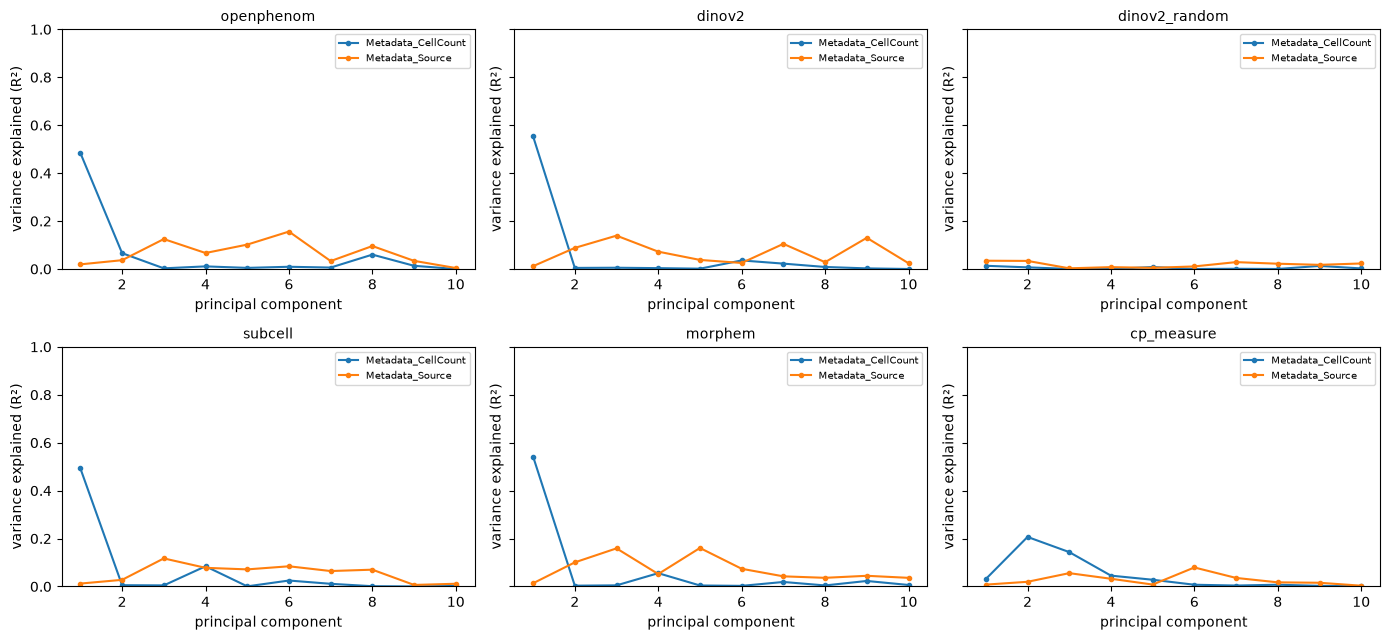

key,cell count,source
openphenom,0.323,0.035
dinov2,0.376,0.030
dinov2_random,0.015,0.019
subcell,0.216,0.034
morphem,0.301,0.044
cp_measure,0.060,0.021


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6.5), sharey=True)
for ax, (model, wells) in zip(axes.ravel(), blocks.items(), strict=True):
    mt.pl.batch_variance(wells, keys=["Metadata_CellCount", "Metadata_Source"], use_rep="X_pca", n_comps=10, ax=ax)
    ax.set_title(model, fontsize=10)
fig.tight_layout()
plt.show()

pd.concat(
    {
        model: mt.metrics.batch_variance_explained(
            wells, keys=["Metadata_CellCount", "Metadata_Source"], use_rep="X_pca"
        ).set_index("key")["value"]
        for model, wells in blocks.items()
    },
    axis=1,
).T.rename(columns={"Metadata_CellCount": "cell count", "Metadata_Source": "source"}).round(3)

On every trained embedding the cell count lands on the first component, and the laboratory is spread thinly
over several later ones. Two controls in that table say what the axis is:

- **`dinov2_random`, untrained, does not do it.** So it is not an artefact of the pipeline or of the images —
  the trained models *learned* to encode how full the well is.
- **`cp_measure` does it far less.** A CellProfiler-style feature is a per-cell measurement averaged over the
  well, and averaging is most of what removes the dependence on how many cells there were. Only most of it,
  though: plenty of named features still track the count, they just do not dominate the leading components.

For a page about swapping the feature block, that is the difference that matters most, and it is a geometry
problem rather than a hit-ranking one — which the next section measures.

## Is the hit a hit, or did the cells die?

This is the question a screener asks first, and on an embedding it is sharper than usual. Call hits, then ask
`tl.cytotoxicity` whether the compounds furthest from the controls are the ones that lost cells.

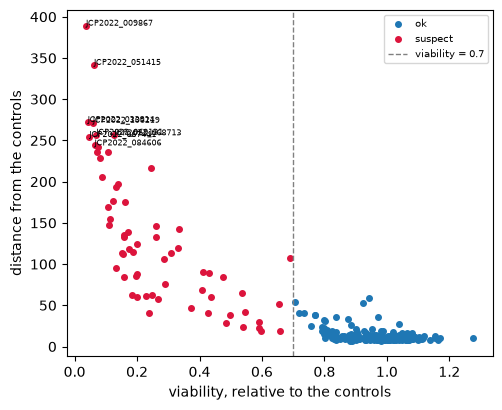

,"rho(distance, viability)",suspect,groups
model,,,
openphenom,-0.654,64,302
dinov2,-0.693,64,302
dinov2_random,-0.535,64,302
subcell,-0.711,64,302
morphem,-0.705,64,302
cp_measure,-0.690,64,302


In [20]:
toxicity = []
for model, wells in blocks.items():
    scratch = wells.copy()
    mt.tl.hit_calling(scratch, use_rep="X_pca", n_permutations=200, seed=0)
    mt.tl.cytotoxicity(scratch, site_key=None)  # one field per well, so there is no field count to divide by
    table = scratch.uns["mantispy"]["cytotoxicity"]
    toxicity.append(
        {
            "model": model,
            "rho(distance, viability)": float(table[["distance", "viability"]].corr(method="spearman").iloc[0, 1]),
            "suspect": int(table["suspect"].sum()),
            "groups": len(table),
        }
    )
    if model == "openphenom":
        mt.pl.cytotoxicity(scratch)
        plt.show()
pd.DataFrame(toxicity).set_index("model").round(3)

The rank correlation is strongly negative on **every** block, the CellProfiler one included. That is worth
stating plainly, because it is easy to assume the embedding's density axis makes it the more confounded
representation: it does not. Cell loss moves a profile away from the controls whichever way you measure it,
because a compound that kills cells has genuinely changed the well. The top of this screen's hit list is
partly a cytotoxicity ranking no matter which feature block you use.

What *is* specific to the embedding is where that lands geometrically: on `cp_measure` the count is one
signal among many, while on a trained embedding it owns the first component. That hurts distances,
neighbourhoods and batch correction rather than hit ranking, which is why it shows up in the PCA panels above
and not in this correlation.

### So should the thin wells go?

The reflex is a floor under the cell count. Before reaching for it, look at which wells it removes.

In [21]:
# Normalizing and selecting never touched obs, so these are the counts as they were loaded.
well_table = embedding.obs
cell_counts = well_table["Metadata_CellCount"].to_numpy(dtype=float)
thin = cell_counts < 50

# Distinct laboratories, not thin wells: nineteen compounds sit in two wells of the same plate, so counting
# wells would call a compound reproducible on the strength of one laboratory twice.
laboratories = well_table[thin].groupby("Metadata_Perturbation", observed=True)["Metadata_Source"].nunique()
{
    "wells under 50 cells": int(thin.sum()),
    "of which controls": int(well_table["Metadata_Control"].to_numpy()[thin].sum()),
    "compounds thin at 2+ of the 4 laboratories": int((laboratories >= 2).sum()),
    "share of thin wells belonging to those": (
        f"{well_table['Metadata_Perturbation'][thin].map(laboratories).ge(2).mean():.0%}"
    ),
}

{'wells under 50 cells': 139,
 'of which controls': 2,
 'compounds thin at 2+ of the 4 laboratories': 33,
 'share of thin wells belonging to those': '83%'}

Almost none are control wells, and most belong to compounds that come out thin at more than one laboratory
independently. That is not a plate that failed, it is cytotoxicity: the compound killed the cells,
reproducibly. A cell-count floor would delete the compounds with the largest effects.

It is also not *only* that — the plate maps at the top of the page showed one laboratory running consistently
sparser than the others, so some of these wells are the plate and some are the compound. Both are true.

And it does not follow that the thin wells carry usable signal. Compare, within each stratum, how much more
alike two wells of the *same* compound are than two wells of different ones.

In [22]:
mt.tl.similarity(embedding, metric="cosine", use_rep="X_pca")
matrix = np.asarray(embedding.obsp["similarity"], dtype=float)
np.fill_diagonal(matrix, np.nan)

compound = embedding.obs["Metadata_Perturbation"].astype(str).to_numpy()
well_counts = embedding.obs["Metadata_CellCount"].to_numpy(dtype=float)
treated = ~embedding.obs["Metadata_Control"].to_numpy()

gaps = []
for label, keep in (
    ("thin (<50 cells)", treated & (well_counts < 50)),
    ("normal (50+)", treated & (well_counts >= 50)),
):
    rows = np.flatnonzero(keep)
    block = matrix[np.ix_(rows, rows)]
    same = compound[rows][:, None] == compound[rows][None, :]
    gaps.append(
        {
            "wells": label,
            "n": rows.size,
            "same compound": np.nanmedian(block[same]),
            "different": np.nanmedian(block[~same]),
        }
    )
gaps = pd.DataFrame(gaps).set_index("wells")
gaps["gap"] = gaps["same compound"] - gaps["different"]
gaps.round(3)

,n,same compound,different,gap
wells,,,,
thin (<50 cells),137,0.712,0.651,0.062
normal (50+),1143,0.751,0.519,0.232


Among the thin wells that gap nearly closes: two thin wells of *different* compounds look almost as alike as
two wells of the same one. Whatever they reproduce, it is mostly emptiness, not the compound.

So both readings were half right. The wells are real biology — cytotoxicity — and their profiles are
nonetheless dominated by density. Measure the two obvious remedies rather than choosing one on principle.

In [23]:
def remedy(treatment):
    """The recipe `prepared` ran, with a cell-count floor or with the count regressed out."""
    if treatment == "none":
        return blocks["openphenom"]  # already built above; rebuilding it is how the two quietly diverge
    wells = mt.ds.jump_lite("openphenom")
    if treatment == "floor":
        wells = wells[wells.obs["Metadata_CellCount"].to_numpy(dtype=float) >= 50].copy()
    mt.pp.normalize(wells, method="mad_robustize", by="Metadata_Plate", reference="negcon")
    wells = wells[:, ~wells.var["degenerate_scale"].to_numpy()].copy()
    if treatment == "regress":
        mt.pp.regress_out(wells, keys=("Metadata_CellCount",), by="Metadata_Plate")
    sc.pp.pca(wells, n_comps=50)
    mt.pp.tvn(wells, batch_key="Metadata_Source", use_rep="X_pca", key_added="X_tvn")
    mt.pp.harmony(wells, batch_key="Metadata_Source", use_rep="X_pca", key_added="X_harmony")
    return wells


remedies = []
for treatment in ("none", "floor", "regress"):
    trial = remedy(treatment)
    left = float(mt.metrics.pc_regression(trial, key="Metadata_CellCount", use_rep="X_pca")["value"].iloc[0])
    for rep in ("X_pca", "X_tvn", "X_harmony"):
        result = scored(treatment, trial, rep)
        remedies.append(
            {
                "treatment": treatment,
                "alignment": rep,
                "wells": trial.n_obs,
                "cell count variance": left,
                "mAP": result["mAP"],
                "significant": result["significant"],
                "target recall": result["target recall"],
                "recall null": result["recall null"],
            }
        )
pd.DataFrame(remedies).set_index(["treatment", "alignment"]).round(3)

wells  cell count variance    mAP  significant  \
treatment alignment                                                   
none      X_pca       1536                0.323  0.016            0   
          X_tvn       1536                0.323  0.018            0   
          X_harmony   1536                0.323  0.040            0   
floor     X_pca       1397                0.250  0.016            0   
          X_tvn       1397                0.250  0.020            0   
          X_harmony   1397                0.250  0.035           18   
regress   X_pca       1536                0.064  0.010            0   
          X_tvn       1536                0.064  0.018            0   
          X_harmony   1536                0.064  0.024            0   

                     target recall  recall null  
treatment alignment                              
none      X_pca              0.057        0.067  
          X_tvn              0.127        0.092  
          X_harmony          0.069        0.082  
floor     X_pca              0.048        0.072  
          X_tvn              0.152        0.111  
          X_harmony          0.048        0.066  
regress   X_pca              0.127        0.094  
          X_tvn              0.161        0.115  
          X_harmony          0.117        0.083

Regressing the count out does what it says: it takes the density axis down, and target recall moves up
against its own null, because the axis it was competing with is gone. What it costs shows up in the mAP
column, and it is not the same cost under every alignment.

That is the trade, and it is the reason to stop rather than to pick a winner. For a **compound** screen the
cell count is partly a *treatment effect* — the compound killed the cells — so regressing it out removes part
of the phenotype, not just a nuisance. The JUMP recipe reflects exactly this: it regresses the cell count out
of the ORF and CRISPR arms, whose plate layouts were not randomized, and does not do it for compounds
{cite:p}`Chandrasekaran_2023`.

So this page keeps every well and does not regress, which is now a decision rather than an omission. What to
do instead is ask the question directly, which is what `tl.cytotoxicity` above is for: report the cell count
beside the readouts, and know that on an embedding it is the first thing the model sees.

Two things that do not transfer:

- **`pp.well_qc` is for single-cell objects.** It counts the rows of each well, so on profiles that are
  already one row per well every well has one row, fails `min_cells`, and the whole plate is flagged. At well
  resolution the equivalent is a threshold on `obs["Metadata_CellCount"]` — the `floor` branch above.
- **scanpy's `sc.pp.filter_cells` and `sc.pp.filter_genes` threshold on counts**, and a morphological profile
  has no counts. The scanpy that does apply is the part already used on this page: `sc.pp.pca`,
  `sc.pp.neighbors` and `sc.tl.umap`, which work because the object is an ordinary `AnnData`.

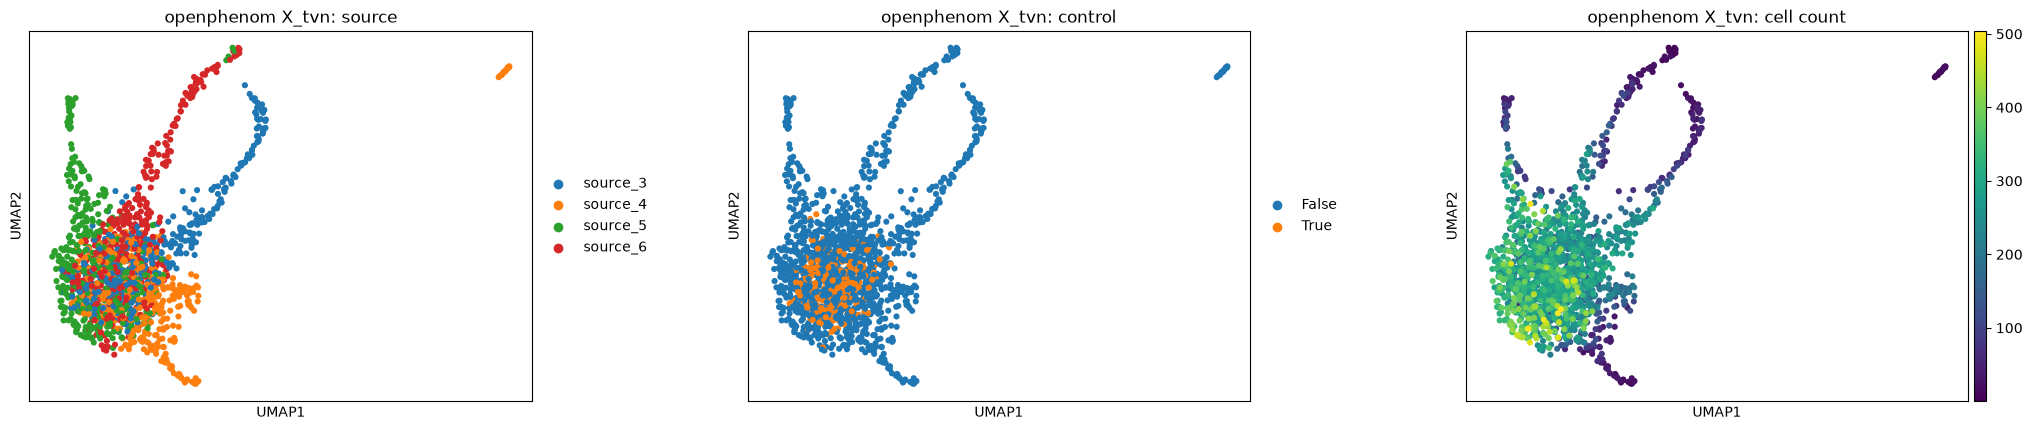

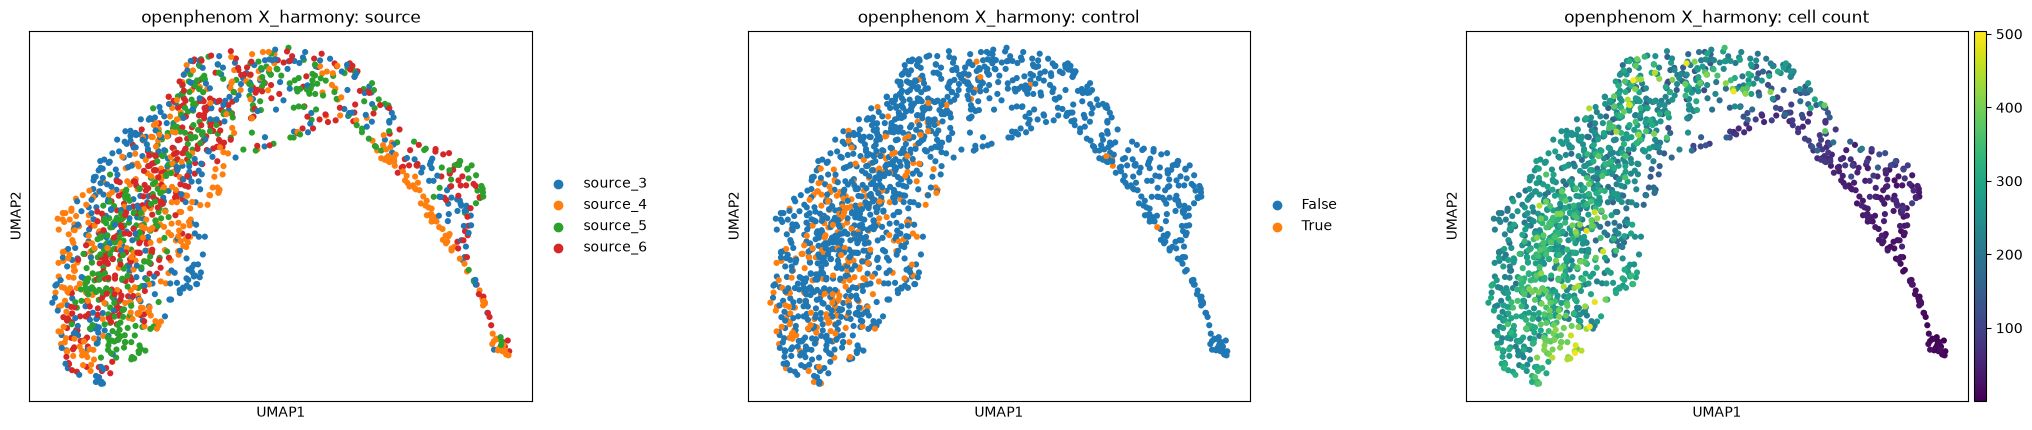

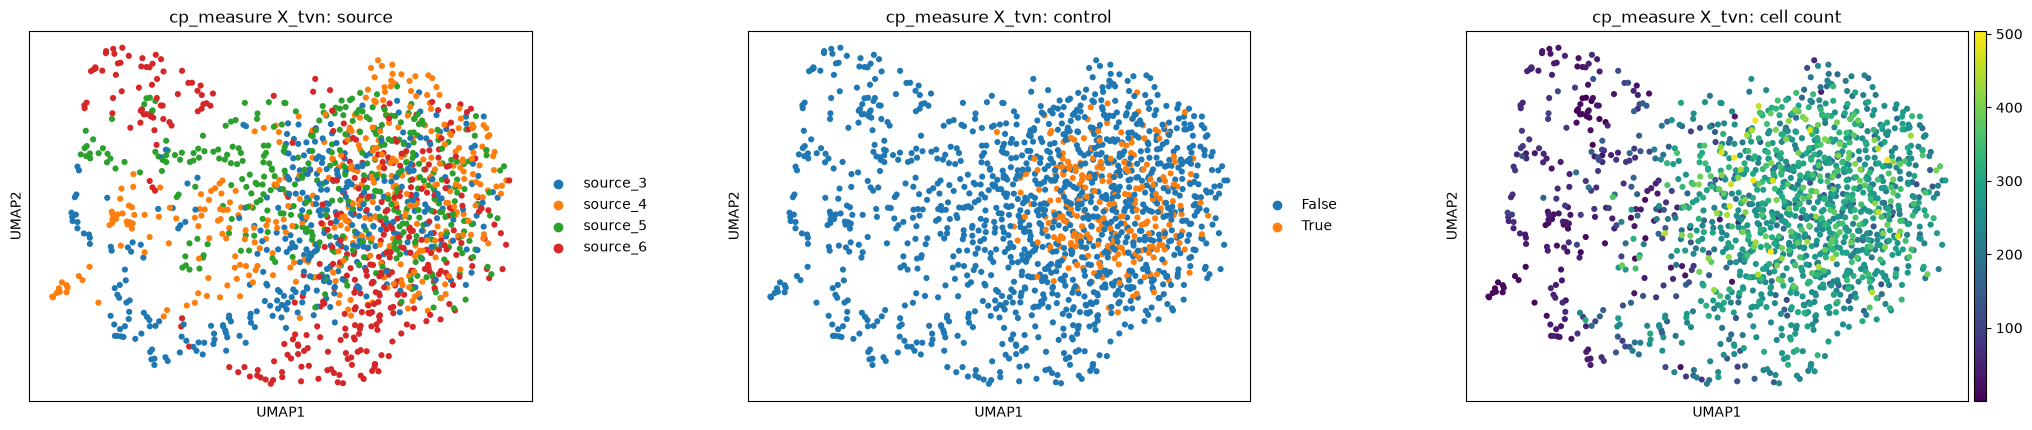

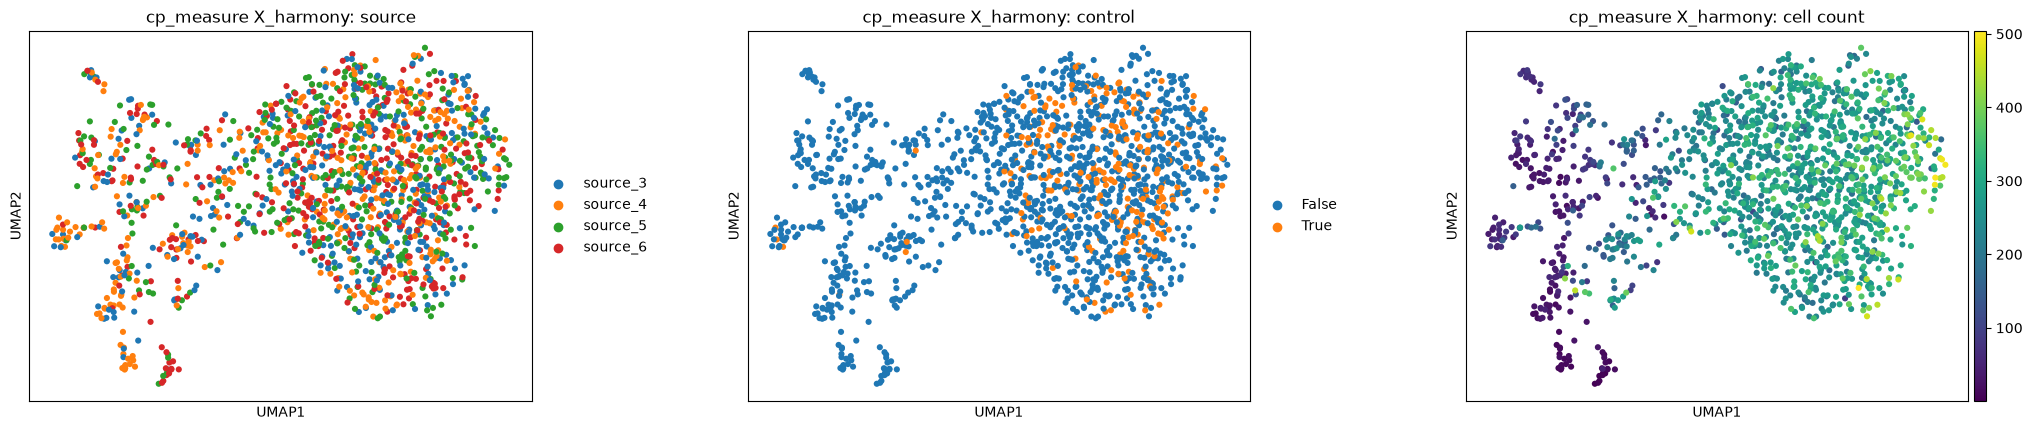

In [24]:
for model in ("openphenom", "cp_measure"):
    wells = blocks[model]
    for rep in ("X_tvn", "X_harmony"):
        sc.pp.neighbors(wells, use_rep=rep)
        sc.tl.umap(wells)
        sc.pl.umap(
            wells,
            color=["Metadata_Source", "Metadata_Control", "Metadata_CellCount"],
            wspace=0.3,
            title=[f"{model} {rep}: source", f"{model} {rep}: control", f"{model} {rep}: cell count"],
        )

Under TVN each source still throws off its own arm; under Harmony they interleave, which is what the
source-variance table already said. The difference between the two feature blocks is visible in the same
panels, and so is the cell-count gradient the previous section measured.

The detached island in the openphenom TVN panel is worth chasing rather than explaining away, and the third
panel already says what it is.

In [25]:
wells = blocks["openphenom"]
sc.pp.neighbors(wells, use_rep="X_tvn")
sc.tl.leiden(wells, key_added="tvn_cluster", flavor="igraph", n_iterations=2, directed=False)

medians = wells.obs.groupby("tvn_cluster", observed=True)["Metadata_CellCount"].median()
island = wells.obs[wells.obs["tvn_cluster"] == medians.idxmin()]
{
    "wells in the emptiest cluster": len(island),
    "sources": island["Metadata_Source"].value_counts()[lambda counts: counts > 0].to_dict(),
    "controls among them": int(island["Metadata_Control"].sum()),
    "median cell count": float(island["Metadata_CellCount"].median()),
    "median elsewhere": float(wells.obs["Metadata_CellCount"].drop(island.index).median()),
}

{'wells in the emptiest cluster': 14,
 'sources': {'source_4': 14},
 'controls among them': 0,
 'median cell count': 11.5,
 'median elsewhere': 252.0}

Clustering the same graph names it: a handful of wells, all from one laboratory, none of them controls, with
a median cell count in the low teens against a couple of hundred everywhere else. They are nearly empty
wells, and a profile averaged over a dozen cells is mostly noise. A correction cannot fix that, and no
aggregate in the tables above would have shown it to you. This is the argument for looking at the embedding
as well as the summary.

## Summary

- An embedding is a feature matrix. Normalization, distances, hit calling, consensus and every metric work on
  it unchanged; `io.stamp` brings one you produced yourself onto the API surface. Cast it to float32 and join
  on the index, not on position.
- `var` carries no compartment or channel, so feature families, feature sets and the blocklist have nothing
  to key on. That is the embedding declining to answer, not missing data — and it is recoverable, because a
  block of named features on the same wells will name the embedding's axes for you.
- Normalize per plate against the controls as usual. **Select features on a CellProfiler block and not on an
  embedding**, and say so: the standard pycytominer selection plus `drop_outliers` is what keeps a handful of
  unbounded moments from becoming the whole representation.
- Keep an untrained model in the comparison. It is the cheapest check that the pipeline measures anything,
  and on this page it caught a chance baseline that was wrong.
- **Measure chance rather than assuming it.** The shuffled-annotation level is a property of each
  representation, not a constant.
- The alignments disagree, and neither dominates. Decide which the screen needs, measure both, and look at
  the embedding as well as the table.

Next: back to [8. Trustworthy features and experimental design](08_trustworthy_features_and_design.ipynb) for
the rest of the benchmarking vocabulary, or [4. Correcting and evaluating](04_correcting_and_evaluating.ipynb)
for the batch-correction methods this page compared TVN against.